# データ分析ひな型
CSVを読み込んでから以下のセルを順番に実行してください。

In [1]:
# Cell 1: CSVを読み込み、以降の分析で使うDataFrameを作成する。
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from dotenv import load_dotenv
import os

matplotlib.rcParams['font.family'] = 'MS Gothic'  # Windows日本語フォント

load_dotenv()
CSV_PATH = os.getenv("VAD_CSV_PATH")
df = pd.read_csv(CSV_PATH)
print("読み込み完了")

読み込み完了


In [2]:
# Cell 2: 行数・列数・列名など、データ全体の基本情報を確認する。
print("=== 行数・列数 ===")
print(f"行数: {len(df)}, 列数: {len(df.columns)}")

print("\n=== 列名と型 ===")
print(df.dtypes)

print("\n=== 先頭5行 ===")
df.head()

=== 行数・列数 ===
行数: 4620, 列数: 19

=== 列名と型 ===
音声ファイル名      object
話者ID         object
性別           object
セリフ          object
演技感情         object
テイク           int64
快不快         float64
活性非活性       float64
狂喜・楽しい        int64
驚き            int64
怒り            int64
恐れ            int64
余裕・嬉しい        int64
冷静            int64
嫌い            int64
軽蔑            int64
リラックス・気楽      int64
眠い・疲れた        int64
憂鬱・悲しい        int64
dtype: object

=== 先頭5行 ===


,音声ファイル名,話者ID,性別,セリフ,演技感情,テイク,快不快,活性非活性,狂喜・楽しい,驚き,怒り,恐れ,余裕・嬉しい,冷静,嫌い,軽蔑,リラックス・気楽,眠い・疲れた,憂鬱・悲しい
0,FA-01-01-1.wav,FA,女性,そうなんですか,狂喜・楽しい,1,9.0,27.0,7,8,0,0,12,0,1,1,5,1,0
1,FA-01-01-2.wav,FA,女性,そうなんですか,狂喜・楽しい,2,11.0,29.0,6,9,0,0,12,2,0,2,4,0,0
2,FA-01-01-3.wav,FA,女性,そうなんですか,狂喜・楽しい,3,0.0,33.0,7,7,0,2,10,1,1,0,2,0,1
3,FA-01-02-1.wav,FA,女性,そうなんですか,驚き,1,-4.0,19.0,2,13,2,2,1,1,1,1,3,1,0
4,FA-01-02-2.wav,FA,女性,そうなんですか,驚き,2,-6.0,7.0,0,12,0,5,0,3,1,0,1,0,5


In [3]:
# Cell 3: 欠損値の数を列ごとに集計し、補正や除外が必要な列を見つける。
print("=== 欠損値の数 ===")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.any() else "欠損値なし")

print("\n=== ユニーク値の数（列ごと） ===")
print(df.nunique())

=== 欠損値の数 ===
快不快      2
活性非活性    3
dtype: int64

=== ユニーク値の数（列ごと） ===
音声ファイル名     4620
話者ID          14
性別             2
セリフ           10
演技感情          11
テイク            3
快不快           65
活性非活性         79
狂喜・楽しい        15
驚き            17
怒り            16
恐れ            15
余裕・嬉しい        16
冷静            16
嫌い            15
軽蔑            15
リラックス・気楽      17
眠い・疲れた        17
憂鬱・悲しい        17
dtype: int64


In [4]:
# Cell 4: カテゴリ列のユニーク値を表示し、ラベル表記や値の揺れを確認する。
for col in df.columns:
    n = df[col].nunique()
    if n <= 30:  # ユニーク値が少ない列はすべて表示
        print(f"\n[{col}] ({n}種類)")
        print(df[col].value_counts().to_string())
    else:
        print(f"\n[{col}] ユニーク値が多い ({n}種類) — 先頭5件: {df[col].head().tolist()}")


[音声ファイル名] ユニーク値が多い (4620種類) — 先頭5件: ['FA-01-01-1.wav', 'FA-01-01-2.wav', 'FA-01-01-3.wav', 'FA-01-02-1.wav', 'FA-01-02-2.wav']

[話者ID] (14種類)
話者ID
FA    330
FB    330
FD    330
FF    330
FG    330
FH    330
FI    330
FL    330
MC    330
ME    330
MJ    330
MK    330
MM    330
MN    330

[性別] (2種類)
性別
女性    2640
男性    1980

[セリフ] (10種類)
セリフ
そうなんですか         462
どうなってるの         462
分かりました          462
ありがとう（ございます）    462
覚えていますか         462
全然嬉しくない         462
それはできない（よ）      462
気にしないで          462
仕方ないな           462
ごめんなさい          462

[演技感情] (11種類)
演技感情
狂喜・楽しい      420
驚き          420
怒り          420
恐れ          420
余裕・嬉しい      420
冷静          420
嫌い          420
軽蔑          420
リラックス・気楽    420
眠い・疲れた      420
憂鬱・悲しい      420

[テイク] (3種類)
テイク
1    1540
2    1540
3    1540

[快不快] ユニーク値が多い (65種類) — 先頭5件: [9.0, 11.0, 0.0, -4.0, -6.0]

[活性非活性] ユニーク値が多い (79種類) — 先頭5件: [27.0, 29.0, 33.0, 19.0, 7.0]

[狂喜・楽しい] (15種類)
狂喜・楽しい
0     2558
1      780
2      380
3      239
4      134
5      100
6

In [5]:
# Cell 5: 数値列の平均・分散・範囲などを確認し、VAD値のスケールを把握する。
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if numeric_cols:
    print("=== 数値列の統計量 ===")
    print(df[numeric_cols].describe().to_string())
else:
    print("数値列なし")

=== 数値列の統計量 ===
               テイク          快不快        活性非活性       狂喜・楽しい           驚き           怒り           恐れ       余裕・嬉しい           冷静           嫌い           軽蔑    リラックス・気楽       眠い・疲れた       憂鬱・悲しい
count  4620.000000  4618.000000  4617.000000  4620.000000  4620.000000  4620.000000  4620.000000  4620.000000  4620.000000  4620.000000  4620.000000  4620.00000  4620.000000  4620.000000
mean      2.000000    -5.062365     1.819147     1.475541     1.744589     1.987229     1.442641     3.142424     4.307576     2.197403     1.406061     4.54329     2.600216     2.908225
std       0.816585    12.159114    15.239182     2.530363     2.728004     3.185410     2.022701     3.325402     3.106605     2.375999     1.879011     3.37420     2.740592     3.205628
min       1.000000   -34.000000   -36.000000     0.000000     0.000000     0.000000     0.000000     0.000000     0.000000     0.000000     0.000000     0.00000     0.000000     0.000000
25%       1.000000   -15.000000   -10.000000     

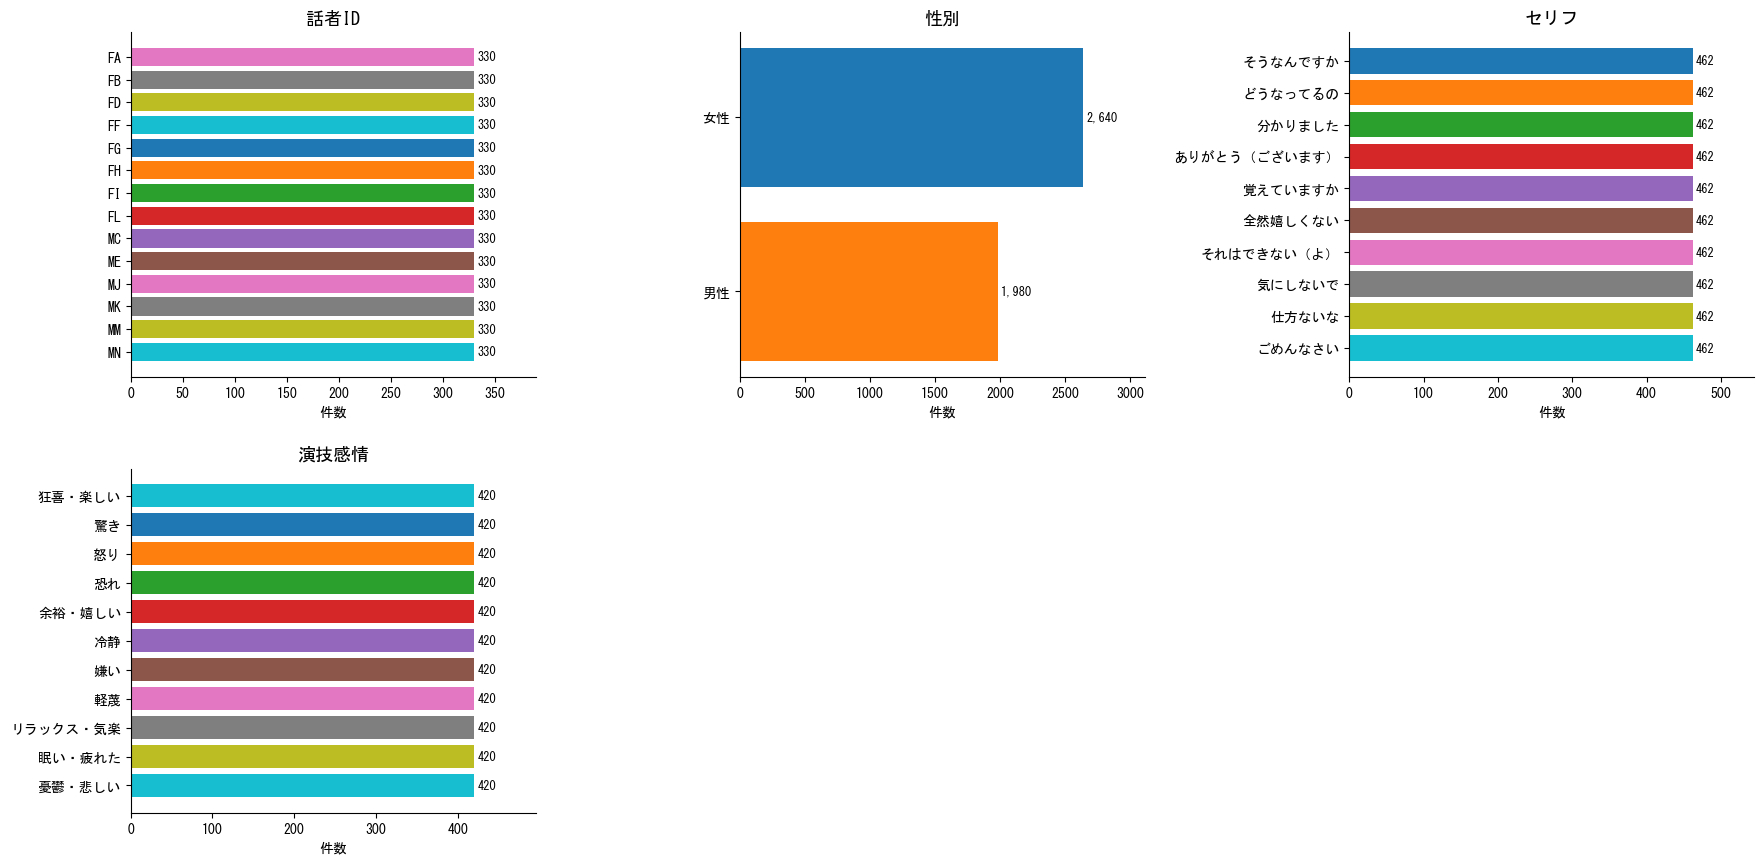

In [6]:
# Cell 6: カテゴリ列の分布を可視化し、クラス偏りやセッション偏りを確認する。
import math

cat_cols = df.select_dtypes(include=[object]).columns.tolist()
# ユニーク値が多すぎる列（IDやファイル名系）は除外
plot_cols = [c for c in cat_cols if df[c].nunique() <= 30]

n = len(plot_cols)
ncols = 3
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4.5 * nrows))
axes = axes.flatten() if n > 1 else [axes]

for ax, col in zip(axes, plot_cols):
    vc = df[col].value_counts()
    colors = plt.cm.tab10.colors[:len(vc)]
    bars = ax.barh(vc.index.astype(str)[::-1], vc.values[::-1], color=colors[::-1])
    ax.set_title(col, fontsize=13, fontweight='bold')
    ax.set_xlabel("件数", fontsize=10)
    # 各バーに件数ラベルを付ける
    for bar, v in zip(bars, vc.values[::-1]):
        ax.text(bar.get_width() + vc.max() * 0.01, bar.get_y() + bar.get_height() / 2,
                f'{v:,}', va='center', fontsize=9)
    ax.set_xlim(0, vc.max() * 1.18)
    ax.spines[['top', 'right']].set_visible(False)

# 余ったサブプロットを非表示
for ax in axes[n:]:
    ax.set_visible(False)

plt.tight_layout(pad=2.0)
plt.show()

In [7]:
# Cell 7: 音声ファイルパスらしい列を探し、実ファイルとの対応確認に使う。
# パスらしき列を自動検出
path_like_cols = [c for c in df.columns if any(k in c.lower() for k in ['file', 'path', 'wav', 'audio'])]
print(f"パス系列の候補: {path_like_cols}")

for col in path_like_cols:
    sample = df[col].dropna().iloc[0] if len(df[col].dropna()) > 0 else None
    print(f"\n[{col}] サンプル値: {sample}")
    # 絶対パスか相対パスか
    from pathlib import PurePath
    if sample:
        p = PurePath(str(sample))
        print(f"  絶対パス判定: {p.is_absolute()}")
        print(f"  拡張子: {p.suffix}")

パス系列の候補: []


## 特定カラムの詳細調査
`TARGET_COL` に調べたいカラム名を指定して実行してください。

=== [快不快]  dtype=float64  ユニーク数=65 ===

── 基本統計量 ──
count    4618.000000
mean       -5.062365
std        12.159114
min       -34.000000
25%       -15.000000
50%        -7.000000
75%         4.000000
max        30.000000

歪度(skewness): 0.3524
尖度(kurtosis): -0.6779


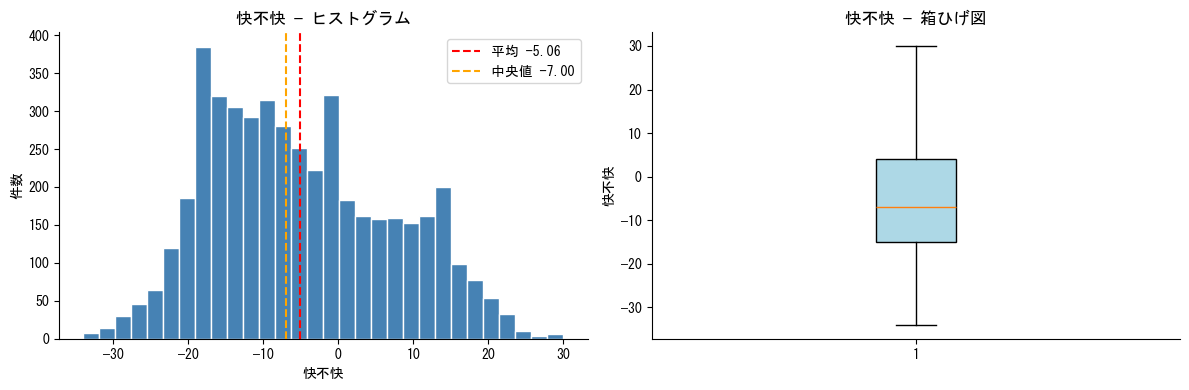

In [8]:
# Cell 8: 指定した列の値を詳しく調べ、正規化や変換の必要性を判断する。
# ↓ ここを変えるだけ
TARGET_COL = "快不快"   # 調べたいカラム名

# ── 存在チェック ──────────────────────────────────────────
if TARGET_COL not in df.columns:
    print(f"列 '{TARGET_COL}' は存在しません。\n利用可能な列: {df.columns.tolist()}")
else:
    s = df[TARGET_COL]
    dtype = s.dtype
    n_unique = s.nunique()

    print(f"=== [{TARGET_COL}]  dtype={dtype}  ユニーク数={n_unique} ===\n")

    # ── 数値列 ────────────────────────────────────────────
    if np.issubdtype(dtype, np.number):
        print("── 基本統計量 ──")
        print(s.describe().to_string())
        print(f"\n歪度(skewness): {s.skew():.4f}")
        print(f"尖度(kurtosis): {s.kurtosis():.4f}")

        fig, axes = plt.subplots(1, 2, figsize=(12, 4))

        axes[0].hist(s.dropna(), bins=30, color='steelblue', edgecolor='white')
        axes[0].set_title(f"{TARGET_COL} — ヒストグラム")
        axes[0].set_xlabel(TARGET_COL)
        axes[0].set_ylabel("件数")
        axes[0].axvline(s.mean(), color='red', linestyle='--', label=f"平均 {s.mean():.2f}")
        axes[0].axvline(s.median(), color='orange', linestyle='--', label=f"中央値 {s.median():.2f}")
        axes[0].legend()

        axes[1].boxplot(s.dropna(), vert=True, patch_artist=True,
                        boxprops=dict(facecolor='lightblue'))
        axes[1].set_title(f"{TARGET_COL} — 箱ひげ図")
        axes[1].set_ylabel(TARGET_COL)

        for ax in axes:
            ax.spines[['top', 'right']].set_visible(False)
        plt.tight_layout()
        plt.show()

    # ── カテゴリ / 文字列列 ──────────────────────────────
    else:
        vc = s.value_counts()
        pct = (vc / len(s) * 100).round(2)
        summary = pd.DataFrame({"件数": vc, "割合(%)": pct})
        print("── 値カウント ──")
        print(summary.to_string())

        if n_unique <= 50:
            fig, ax = plt.subplots(figsize=(8, max(3, n_unique * 0.4)))
            colors = plt.cm.tab20.colors
            bars = ax.barh(vc.index.astype(str)[::-1], vc.values[::-1],
                           color=[colors[i % len(colors)] for i in range(len(vc))][::-1])
            ax.set_title(f"{TARGET_COL} — 値の分布", fontsize=13, fontweight='bold')
            ax.set_xlabel("件数")
            for bar, v in zip(bars, vc.values[::-1]):
                ax.text(bar.get_width() + vc.max() * 0.01,
                        bar.get_y() + bar.get_height() / 2,
                        f'{v:,}', va='center', fontsize=9)
            ax.set_xlim(0, vc.max() * 1.18)
            ax.spines[['top', 'right']].set_visible(False)
            plt.tight_layout()
            plt.show()
        else:
            print(f"\nユニーク値が多い({n_unique}種)ためグラフは省略。先頭20件:")
            print(vc.head(20).to_string())

In [9]:
# Cell 9: 評定値を16で割って0から1程度の範囲へ正規化した統計量を確認する。
for col in ["快不快", "活性非活性"]:
    normalized = df[col] / 16
    print(f"=== {col} ÷ 16 ===")
    print(normalized.describe().to_string())
    print(f"min: {normalized.min():.4f},  max: {normalized.max():.4f}")
    print()

=== 快不快 ÷ 16 ===
count    4618.000000
mean       -0.316398
std         0.759945
min        -2.125000
25%        -0.937500
50%        -0.437500
75%         0.250000
max         1.875000
min: -2.1250,  max: 1.8750

=== 活性非活性 ÷ 16 ===
count    4617.000000
mean        0.113697
std         0.952449
min        -2.250000
25%        -0.625000
50%         0.062500
75%         0.812500
max         2.687500
min: -2.2500,  max: 2.6875



In [10]:
# Cell 10: 正規化済み列を追加したCSVを保存し、後続のVAD学習用データにする。
df["快不快_norm"] = df["快不快"] / 16
df["活性非活性_norm"] = df["活性非活性"] / 16

save_path = CSV_PATH.replace(".csv", "_normalized.csv")
df.to_csv(save_path, index=False, encoding="utf-8-sig")
print(f"保存完了: {save_path}")
print(df[["快不快", "快不快_norm", "活性非活性", "活性非活性_norm"]].head())

保存完了: C:\Users\RD004\Documents\lab\data\HCUDB1\HCUDB1\eval\collected_result(all)_normalized.csv
    快不快  快不快_norm  活性非活性  活性非活性_norm
0   9.0    0.5625   27.0      1.6875
1  11.0    0.6875   29.0      1.8125
2   0.0    0.0000   33.0      2.0625
3  -4.0   -0.2500   19.0      1.1875
4  -6.0   -0.3750    7.0      0.4375
